# Tiny Graphs - Neural Network (Graph: Cycle)

## 1) Tiny cycle (High Weight Decay/No Dropout -- Reasonable LR)


In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [2]:
cycle_v1_seed = 7

cycle_v1_train_from_scratch = True
cycle_v1_checkpoint_path = ""
cycle_v1_embedding_history_path = ""
cycle_v1_topk_history_path = ""
cycle_v1_dataset_overwrite = False

cycle_v1_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 2, # HIGH WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [3]:
cycle_v1_context = build_transformer_section_context(
    cycle_v1_cli_config,
    seed=cycle_v1_seed,
    dataset_overwrite=cycle_v1_dataset_overwrite,
)

cycle_v1_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v1_context,
    train_from_scratch=cycle_v1_train_from_scratch,
    checkpoint_path=cycle_v1_checkpoint_path,
)

print("Run name:", cycle_v1_context.args.run_name)
print("Checkpoint:", cycle_v1_resolved_checkpoint_path)
print("Pretrain file:", cycle_v1_context.pretrain_path)
print("Train file:", cycle_v1_context.train_path)
print("Test file:", cycle_v1_context.test_path)
print("Archived checkpoint:", cycle_v1_context.checkpoint_path)
print("Embedding history pickle:", cycle_v1_context.embedding_history_path)
print("Top-k pickle:", cycle_v1_context.topk_history_path)
print("Manifest:", cycle_v1_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/1000 [00:00<?, ?it/s]


Edge accuracy improved to 50.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215718/checkpoints/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215718_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 50.00%
Run name: in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215718
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task

In [4]:
cycle_v1_eval_metrics = evaluate_edge_and_path(cycle_v1_context)

print_evaluation_report("Tiny cycle (V1)", cycle_v1_eval_metrics)


Edge Memorization | Loss: 0.7544 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 67.07it/s]


Edge Memorization | Loss: 0.7544 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 147.42it/s]

Tiny cycle (V1) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [5]:
cycle_v1_node_embeddings, cycle_v1_edge_list, cycle_v1_root_node_index = collect_embeddings_and_edges(cycle_v1_context)

cycle_v1_embedding_history, cycle_v1_topk_recovery_history = load_analysis_histories(
    cycle_v1_context,
    cycle_v1_edge_list,
    embedding_history_path=cycle_v1_embedding_history_path,
    topk_history_path=cycle_v1_topk_history_path,
)

if not cycle_v1_embedding_history:
    cycle_v1_embedding_history = {0: cycle_v1_node_embeddings}
if not cycle_v1_topk_recovery_history:
    cycle_v1_topk_recovery_history = {0: cycle_v1_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v1_node_embeddings.shape)
print("Number of edges:", len(cycle_v1_edge_list))
print("Root node index:", cycle_v1_root_node_index)
print("Embedding history steps:", len(cycle_v1_embedding_history))
print("Top-k history steps:", len(cycle_v1_topk_recovery_history))


Node embedding shape: (15, 32)
Number of edges: 30
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [6]:
# Reduction config for this block (kept local to reduction stage)
cycle_v1_use_umap = False
cycle_v1_reduction_dim = 5
cycle_v1_umap_n_neighbors = 4
cycle_v1_umap_min_dist = 0.3

cycle_v1_reduced_full, cycle_v1_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v1_node_embeddings,
    use_umap=cycle_v1_use_umap,
    reduction_dim=cycle_v1_reduction_dim,
    seed=cycle_v1_seed,
    umap_n_neighbors=cycle_v1_umap_n_neighbors,
    umap_min_dist=cycle_v1_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v1_reduced_embeddings = cycle_v1_reduced_full[:, :3]
print("Reduced full shape:", cycle_v1_reduced_full.shape)
print("Reduced xyz shape:", cycle_v1_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

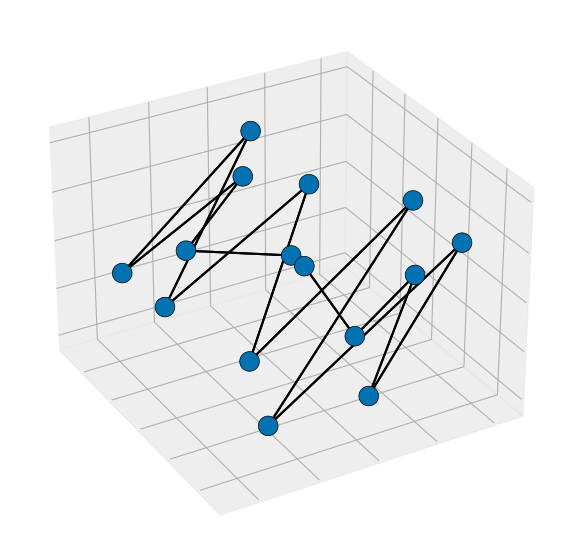

In [7]:
%matplotlib inline
# %matplotlib widget

cycle_v1_raw_elev = 30
cycle_v1_raw_azim = -30
cycle_v1_raw_roll = 0

# Styled plotting constants for this block
cycle_v1_styled_view = {"elev": cycle_v1_raw_elev, "azim": cycle_v1_raw_azim, "roll": cycle_v1_raw_roll}
cycle_v1_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v1_reduced_embeddings,
    cycle_v1_edge_list,
    title="",
    view=cycle_v1_styled_view,
    root_node_index=cycle_v1_root_node_index,
    axis_permutation=cycle_v1_styled_axis_permutation,
);

################
#Another Angle
################

# cycle_v1_raw_elev = 20
# cycle_v1_raw_azim = 0
# cycle_v1_raw_roll = 0

# # Styled plotting constants for this block
# cycle_v1_styled_view = {"elev": cycle_v1_raw_elev, "azim": cycle_v1_raw_azim, "roll": cycle_v1_raw_roll}
# cycle_v1_styled_axis_permutation = (0, 1, 2)

# plot_stylized_embedding_graph(
#     cycle_v1_reduced_embeddings,
#     cycle_v1_edge_list,
#     title="",
#     view=cycle_v1_styled_view,
#     root_node_index=cycle_v1_root_node_index,
#     axis_permutation=cycle_v1_styled_axis_permutation,
# );


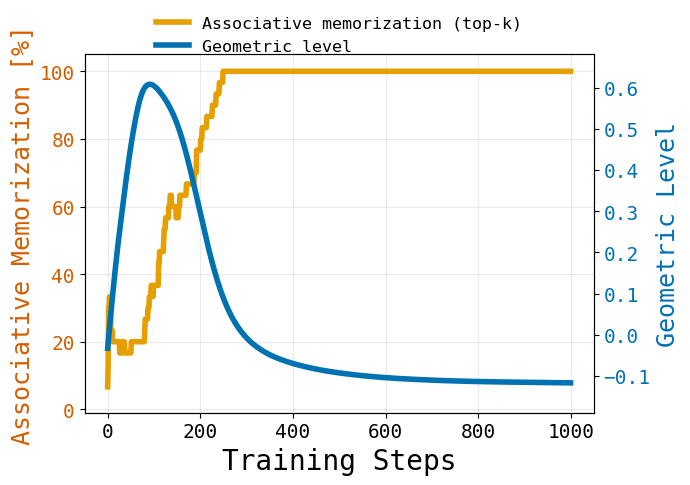

In [8]:
# Line-plot constants for this block
cycle_v1_line_plot_title = ""

cycle_v1_curve_steps, cycle_v1_curve_associative, cycle_v1_curve_geometric = compute_associative_geometric_curves(
    cycle_v1_embedding_history,
    cycle_v1_topk_recovery_history,
    cycle_v1_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v1_curve_steps,
    associative_scores=cycle_v1_curve_associative,
    geometric_scores=cycle_v1_curve_geometric,
    title=cycle_v1_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `cycle_heatmap_epoch` to one of the highest geometric_level epochs.

cycle heatmap epoch: 999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


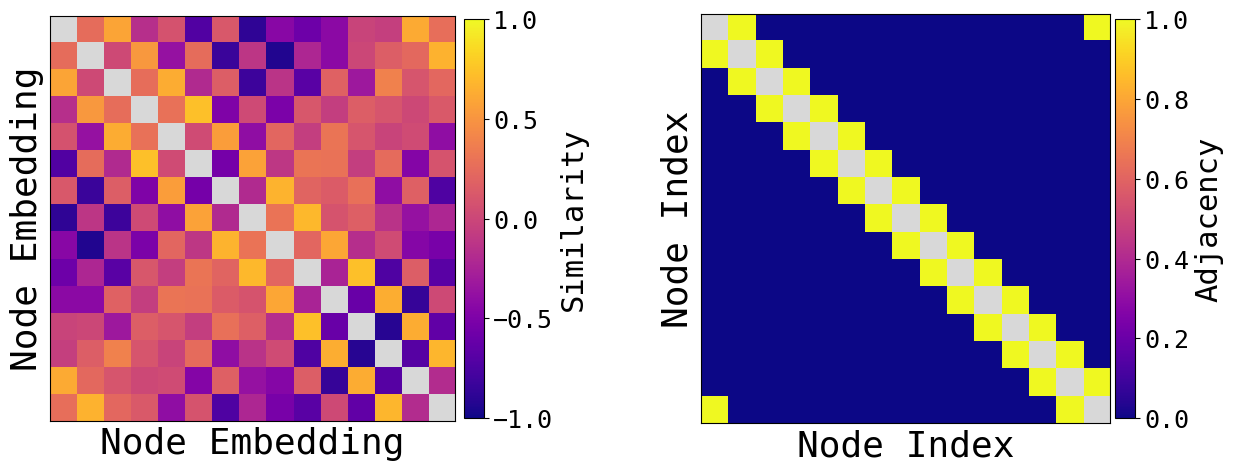

In [9]:
# Heatmap constants for this block
cycle_v1_heatmap_graph_type = cycle_v1_context.args.graph_type
cycle_v1_heatmap_epoch = -1
cycle_v1_heatmap_cmap_name = "plasma"
cycle_v1_heatmap_wspace = 0.5

cycle_v1_heatmap_embeddings, cycle_v1_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v1_embedding_history,
    fallback_embeddings=cycle_v1_node_embeddings,
    requested_step=cycle_v1_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v1_heatmap_resolved_epoch)
cycle_v1_heatmap_order = list(range(cycle_v1_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v1_heatmap_order), 4):
    row = cycle_v1_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v1_heatmap_embeddings,
    edge_list=cycle_v1_edge_list,
    graph_type=cycle_v1_heatmap_graph_type,
    root_node_index=cycle_v1_root_node_index,
    custom_order=cycle_v1_heatmap_order,
    cmap_name=cycle_v1_heatmap_cmap_name,
    wspace=cycle_v1_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [10]:
# Laplacian geometry constants for this block
cycle_v1_laplacian_axis_indices = (-2, -3, -4)
cycle_v1_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v1_edge_list,
    node_count=cycle_v1_node_embeddings.shape[0],
)

cycle normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]


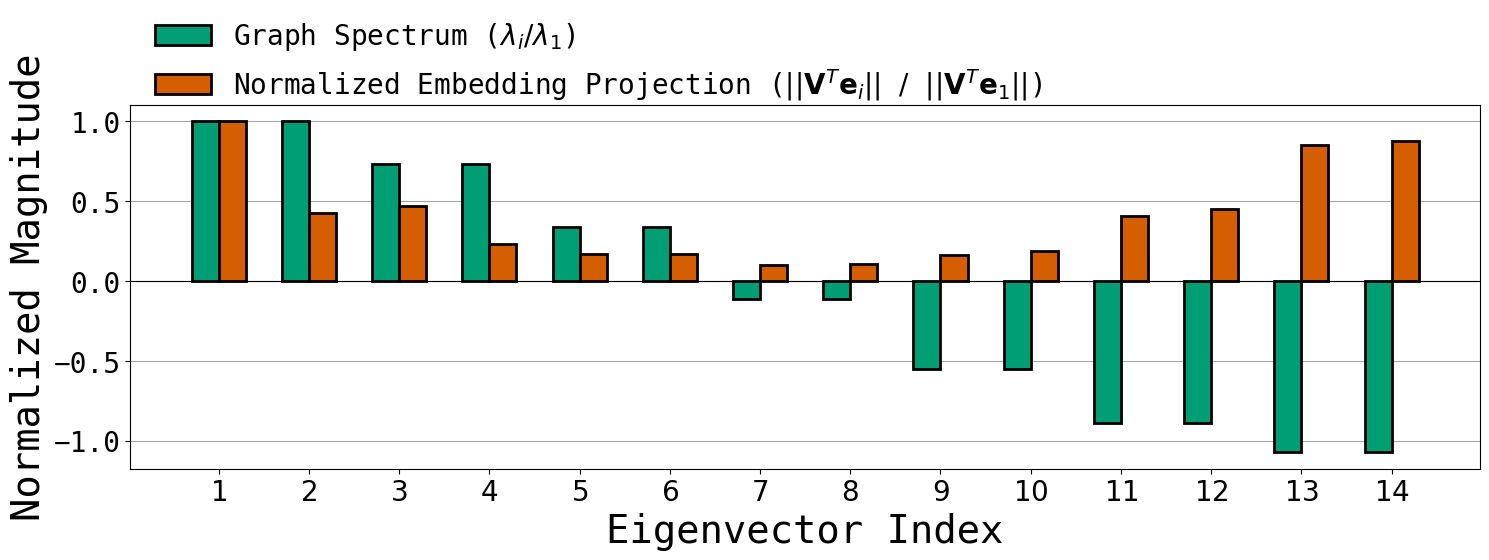

In [11]:
# Spectral-bias constants for this block
cycle_v1_spectral_drop_top_eigenvector = True
cycle_v1_spectral_reorder_prefix = None
cycle_v1_spectral_cutoff = None
cycle_v1_spectral_figsize = (15.0, 6.0)
cycle_v1_spectral_legend_anchor = (0.0, 1.3)

cycle_v1_norm_eigenvalues, cycle_v1_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v1_node_embeddings,
    spectral_state=cycle_v1_spectral_state,
    drop_top_eigenvector=cycle_v1_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v1_spectral_reorder_prefix,
)

print("cycle normalized eigenvalues:\n", cycle_v1_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=cycle_v1_norm_eigenvalues,
    norm_projections=cycle_v1_norm_projections,
    title="",
    cutoff=cycle_v1_spectral_cutoff,
    figsize=cycle_v1_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v1_spectral_legend_anchor,
    save=True,
    filename=f"{cycle_v1_context.args.graph_type}_{cycle_v1_context.args.model_architecture_label}_eigen_projection_v1"
);


## 2) Tiny cycle (High Dropout/No Weight Decay -- Reasonable LR)


In [12]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [13]:
cycle_v2_seed = 7

cycle_v2_train_from_scratch = True
cycle_v2_checkpoint_path = ""
cycle_v2_embedding_history_path = ""
cycle_v2_topk_history_path = ""
cycle_v2_dataset_overwrite = False

cycle_v2_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0, # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.5, # WITH DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [14]:
cycle_v2_context = build_transformer_section_context(
    cycle_v2_cli_config,
    seed=cycle_v2_seed,
    dataset_overwrite=cycle_v2_dataset_overwrite,
)

cycle_v2_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v2_context,
    train_from_scratch=cycle_v2_train_from_scratch,
    checkpoint_path=cycle_v2_checkpoint_path,
)

print("Run name:", cycle_v2_context.args.run_name)
print("Checkpoint:", cycle_v2_resolved_checkpoint_path)
print("Pretrain file:", cycle_v2_context.pretrain_path)
print("Train file:", cycle_v2_context.train_path)
print("Test file:", cycle_v2_context.test_path)
print("Archived checkpoint:", cycle_v2_context.checkpoint_path)
print("Embedding history pickle:", cycle_v2_context.embedding_history_path)
print("Top-k pickle:", cycle_v2_context.topk_history_path)
print("Manifest:", cycle_v2_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/1000 [00:00<?, ?it/s]


Edge accuracy improved to 60.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215646/checkpoints/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215646_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 60.00%
Run name: in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215646
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task

In [15]:
cycle_v2_eval_metrics = evaluate_edge_and_path(cycle_v2_context)

print_evaluation_report("Tiny cycle (V2)", cycle_v2_eval_metrics)


Edge Memorization | Loss: 0.7258 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 158.69it/s]


Edge Memorization | Loss: 0.7258 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 166.28it/s]

Tiny cycle (V2) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [16]:
cycle_v2_node_embeddings, cycle_v2_edge_list, cycle_v2_root_node_index = collect_embeddings_and_edges(cycle_v2_context)

cycle_v2_embedding_history, cycle_v2_topk_recovery_history = load_analysis_histories(
    cycle_v2_context,
    cycle_v2_edge_list,
    embedding_history_path=cycle_v2_embedding_history_path,
    topk_history_path=cycle_v2_topk_history_path,
)

if not cycle_v2_embedding_history:
    cycle_v2_embedding_history = {0: cycle_v2_node_embeddings}
if not cycle_v2_topk_recovery_history:
    cycle_v2_topk_recovery_history = {0: cycle_v2_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v2_node_embeddings.shape)
print("Number of edges:", len(cycle_v2_edge_list))
print("Root node index:", cycle_v2_root_node_index)
print("Embedding history steps:", len(cycle_v2_embedding_history))
print("Top-k history steps:", len(cycle_v2_topk_recovery_history))


Node embedding shape: (15, 32)
Number of edges: 30
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [17]:
# Reduction config for this block (kept local to reduction stage)
cycle_v2_use_umap = False
cycle_v2_reduction_dim = 5
cycle_v2_umap_n_neighbors = 4
cycle_v2_umap_min_dist = 0.3

cycle_v2_reduced_full, cycle_v2_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v2_node_embeddings,
    use_umap=cycle_v2_use_umap,
    reduction_dim=cycle_v2_reduction_dim,
    seed=cycle_v2_seed,
    umap_n_neighbors=cycle_v2_umap_n_neighbors,
    umap_min_dist=cycle_v2_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v2_reduced_embeddings = cycle_v2_reduced_full[:, :3]
print("Reduced full shape:", cycle_v2_reduced_full.shape)
print("Reduced xyz shape:", cycle_v2_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

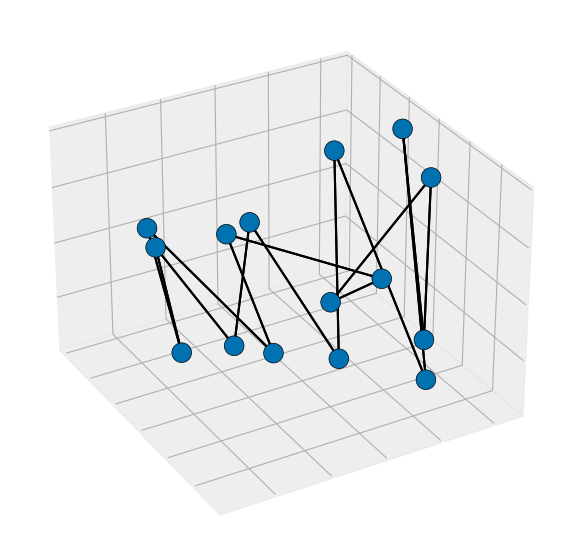

In [18]:
%matplotlib inline
# %matplotlib widget

cycle_v2_raw_elev = 30
cycle_v2_raw_azim = -30
cycle_v2_raw_roll = 0

# Styled plotting constants for this block
cycle_v2_styled_view = {"elev": cycle_v2_raw_elev, "azim": cycle_v2_raw_azim, "roll": cycle_v2_raw_roll}
cycle_v2_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v2_reduced_embeddings,
    cycle_v2_edge_list,
    title="",
    view=cycle_v2_styled_view,
    root_node_index=cycle_v2_root_node_index,
    axis_permutation=cycle_v2_styled_axis_permutation,
);

################
#Another Angle
################

# cycle_v2_raw_elev = 20
# cycle_v2_raw_azim = 0
# cycle_v2_raw_roll = 0

# # Styled plotting constants for this block
# cycle_v2_styled_view = {"elev": cycle_v2_raw_elev, "azim": cycle_v2_raw_azim, "roll": cycle_v2_raw_roll}
# cycle_v2_styled_axis_permutation = (0, 1, 2)

# plot_stylized_embedding_graph(
#     cycle_v2_reduced_embeddings,
#     cycle_v2_edge_list,
#     title="",
#     view=cycle_v2_styled_view,
#     root_node_index=cycle_v2_root_node_index,
#     axis_permutation=cycle_v2_styled_axis_permutation,
# );


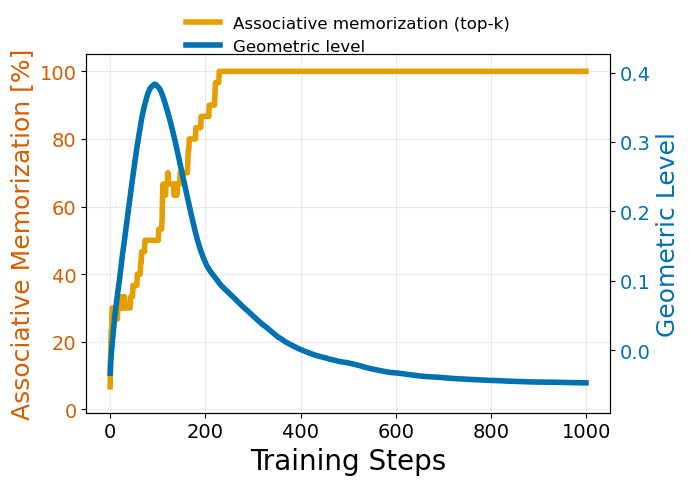

In [19]:
# Line-plot constants for this block
cycle_v2_line_plot_title = ""

cycle_v2_curve_steps, cycle_v2_curve_associative, cycle_v2_curve_geometric = compute_associative_geometric_curves(
    cycle_v2_embedding_history,
    cycle_v2_topk_recovery_history,
    cycle_v2_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v2_curve_steps,
    associative_scores=cycle_v2_curve_associative,
    geometric_scores=cycle_v2_curve_geometric,
    title=cycle_v2_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `cycle_heatmap_epoch` to one of the highest geometric_level epochs.

cycle heatmap epoch: 999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


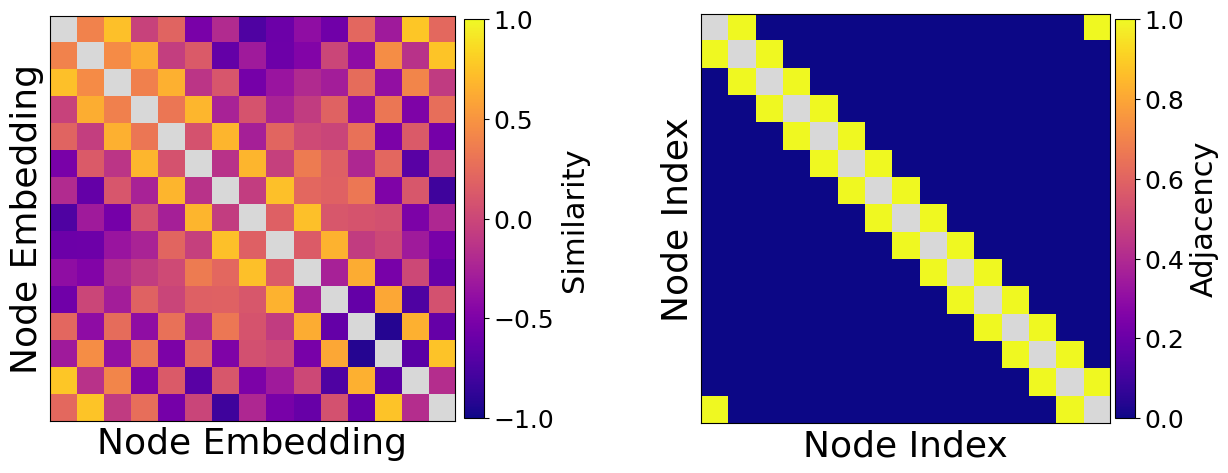

In [20]:
# Heatmap constants for this block
cycle_v2_heatmap_graph_type = cycle_v2_context.args.graph_type
cycle_v2_heatmap_epoch = -1
cycle_v2_heatmap_cmap_name = "plasma"
cycle_v2_heatmap_wspace = 0.5

cycle_v2_heatmap_embeddings, cycle_v2_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v2_embedding_history,
    fallback_embeddings=cycle_v2_node_embeddings,
    requested_step=cycle_v2_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v2_heatmap_resolved_epoch)
cycle_v2_heatmap_order = list(range(cycle_v2_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v2_heatmap_order), 4):
    row = cycle_v2_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v2_heatmap_embeddings,
    edge_list=cycle_v2_edge_list,
    graph_type=cycle_v2_heatmap_graph_type,
    root_node_index=cycle_v2_root_node_index,
    custom_order=cycle_v2_heatmap_order,
    cmap_name=cycle_v2_heatmap_cmap_name,
    wspace=cycle_v2_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [21]:
# Laplacian geometry constants for this block
cycle_v2_laplacian_axis_indices = (-2, -3, -4)
cycle_v2_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v2_edge_list,
    node_count=cycle_v2_node_embeddings.shape[0],
)

cycle normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]


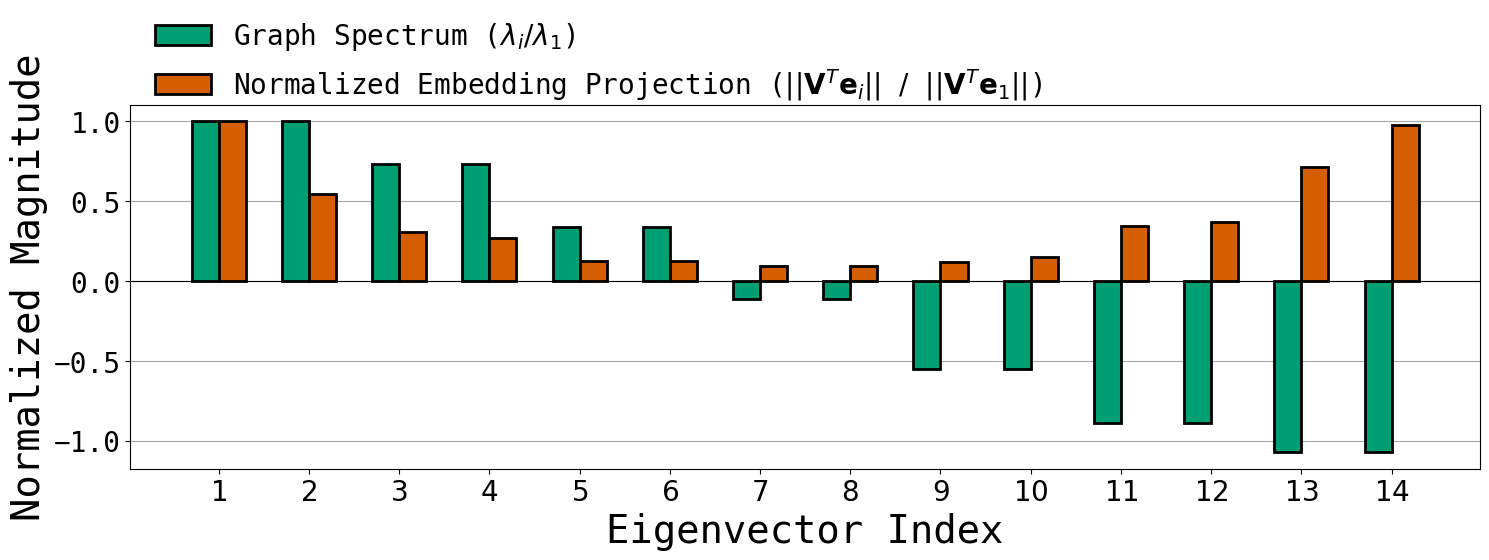

In [22]:
# Spectral-bias constants for this block
cycle_v2_spectral_drop_top_eigenvector = True
cycle_v2_spectral_reorder_prefix = None
cycle_v2_spectral_cutoff = None
cycle_v2_spectral_figsize = (15.0, 6.0)
cycle_v2_spectral_legend_anchor = (0.0, 1.3)

cycle_v2_norm_eigenvalues, cycle_v2_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v2_node_embeddings,
    spectral_state=cycle_v2_spectral_state,
    drop_top_eigenvector=cycle_v2_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v2_spectral_reorder_prefix,
)

print("cycle normalized eigenvalues:\n", cycle_v2_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=cycle_v2_norm_eigenvalues,
    norm_projections=cycle_v2_norm_projections,
    title="",
    cutoff=cycle_v2_spectral_cutoff,
    figsize=cycle_v2_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v2_spectral_legend_anchor,
    save=True,
    filename=f"{cycle_v2_context.args.graph_type}_{cycle_v2_context.args.model_architecture_label}_eigen_projection_v2"
);


## 3) Tiny cycle (No Weight Decay/Dropout -- Reasonable LR)


In [23]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [24]:
cycle_v3_seed = 7

cycle_v3_train_from_scratch = True
cycle_v3_checkpoint_path = ""
cycle_v3_embedding_history_path = ""
cycle_v3_topk_history_path = ""
cycle_v3_dataset_overwrite = False

cycle_v3_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0., # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [25]:
cycle_v3_context = build_transformer_section_context(
    cycle_v3_cli_config,
    seed=cycle_v3_seed,
    dataset_overwrite=cycle_v3_dataset_overwrite,
)

cycle_v3_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v3_context,
    train_from_scratch=cycle_v3_train_from_scratch,
    checkpoint_path=cycle_v3_checkpoint_path,
)

print("Run name:", cycle_v3_context.args.run_name)
print("Checkpoint:", cycle_v3_resolved_checkpoint_path)
print("Pretrain file:", cycle_v3_context.pretrain_path)
print("Train file:", cycle_v3_context.train_path)
print("Test file:", cycle_v3_context.test_path)
print("Archived checkpoint:", cycle_v3_context.checkpoint_path)
print("Embedding history pickle:", cycle_v3_context.embedding_history_path)
print("Top-k pickle:", cycle_v3_context.topk_history_path)
print("Manifest:", cycle_v3_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/1000 [00:00<?, ?it/s]


Edge accuracy improved to 50.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215816/checkpoints/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215816_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 50.00%
Run name: in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215816
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task

In [26]:
cycle_v3_eval_metrics = evaluate_edge_and_path(cycle_v3_context)

print_evaluation_report("Tiny cycle (V3)", cycle_v3_eval_metrics)


Edge Memorization | Loss: 0.6992 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 68.84it/s]


Edge Memorization | Loss: 0.6992 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 57.65it/s]

Tiny cycle (V3) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [27]:
cycle_v3_node_embeddings, cycle_v3_edge_list, cycle_v3_root_node_index = collect_embeddings_and_edges(cycle_v3_context)

cycle_v3_embedding_history, cycle_v3_topk_recovery_history = load_analysis_histories(
    cycle_v3_context,
    cycle_v3_edge_list,
    embedding_history_path=cycle_v3_embedding_history_path,
    topk_history_path=cycle_v3_topk_history_path,
)

if not cycle_v3_embedding_history:
    cycle_v3_embedding_history = {0: cycle_v3_node_embeddings}
if not cycle_v3_topk_recovery_history:
    cycle_v3_topk_recovery_history = {0: cycle_v3_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v3_node_embeddings.shape)
print("Number of edges:", len(cycle_v3_edge_list))
print("Root node index:", cycle_v3_root_node_index)
print("Embedding history steps:", len(cycle_v3_embedding_history))
print("Top-k history steps:", len(cycle_v3_topk_recovery_history))


Node embedding shape: (15, 32)
Number of edges: 30
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [28]:
# Reduction config for this block (kept local to reduction stage)
cycle_v3_use_umap = False
cycle_v3_reduction_dim = 5
cycle_v3_umap_n_neighbors = 4
cycle_v3_umap_min_dist = 0.3

cycle_v3_reduced_full, cycle_v3_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v3_node_embeddings,
    use_umap=cycle_v3_use_umap,
    reduction_dim=cycle_v3_reduction_dim,
    seed=cycle_v3_seed,
    umap_n_neighbors=cycle_v3_umap_n_neighbors,
    umap_min_dist=cycle_v3_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v3_reduced_embeddings = cycle_v3_reduced_full[:, :3]
print("Reduced full shape:", cycle_v3_reduced_full.shape)
print("Reduced xyz shape:", cycle_v3_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

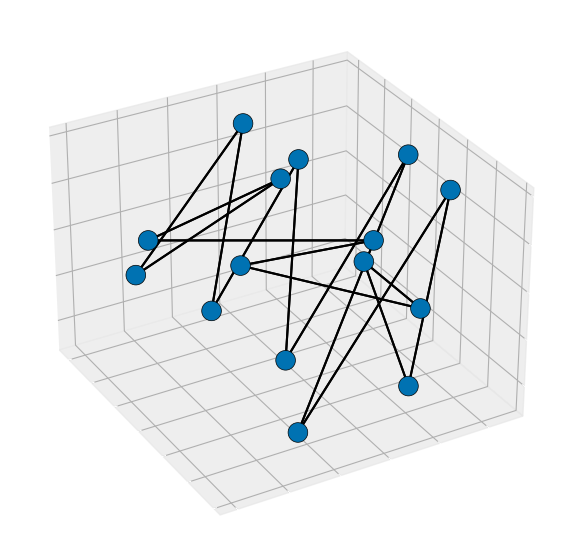

In [29]:
%matplotlib inline
# %matplotlib widget

cycle_v3_raw_elev = 30
cycle_v3_raw_azim = -30
cycle_v3_raw_roll = 0

# Styled plotting constants for this block
cycle_v3_styled_view = {"elev": cycle_v3_raw_elev, "azim": cycle_v3_raw_azim, "roll": cycle_v3_raw_roll}
cycle_v3_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v3_reduced_embeddings,
    cycle_v3_edge_list,
    title="",
    view=cycle_v3_styled_view,
    root_node_index=cycle_v3_root_node_index,
    axis_permutation=cycle_v3_styled_axis_permutation,
);

################
#Another Angle
################

# cycle_v3_raw_elev = 20
# cycle_v3_raw_azim = 0
# cycle_v3_raw_roll = 0

# # Styled plotting constants for this block
# cycle_v3_styled_view = {"elev": cycle_v3_raw_elev, "azim": cycle_v3_raw_azim, "roll": cycle_v3_raw_roll}
# cycle_v3_styled_axis_permutation = (0, 1, 2)

# plot_stylized_embedding_graph(
#     cycle_v3_reduced_embeddings,
#     cycle_v3_edge_list,
#     title="",
#     view=cycle_v3_styled_view,
#     root_node_index=cycle_v3_root_node_index,
#     axis_permutation=cycle_v3_styled_axis_permutation,
# );


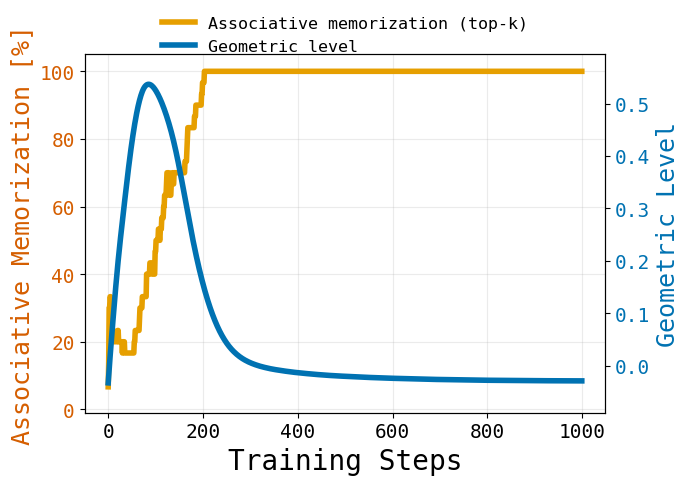

In [30]:
# Line-plot constants for this block
cycle_v3_line_plot_title = ""

cycle_v3_curve_steps, cycle_v3_curve_associative, cycle_v3_curve_geometric = compute_associative_geometric_curves(
    cycle_v3_embedding_history,
    cycle_v3_topk_recovery_history,
    cycle_v3_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v3_curve_steps,
    associative_scores=cycle_v3_curve_associative,
    geometric_scores=cycle_v3_curve_geometric,
    title=cycle_v3_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `cycle_heatmap_epoch` to one of the highest geometric_level epochs.

cycle heatmap epoch: 999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


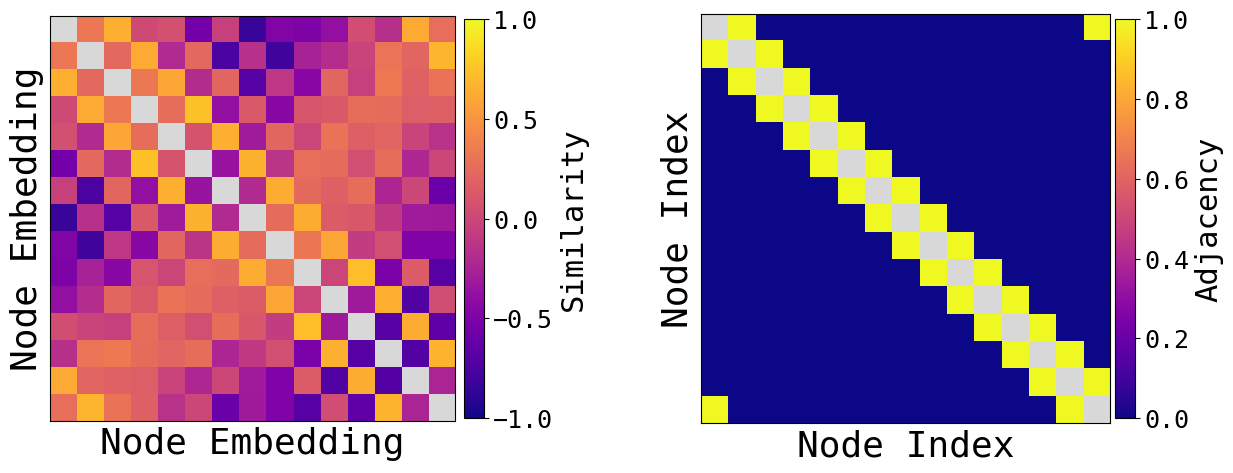

In [31]:
# Heatmap constants for this block
cycle_v3_heatmap_graph_type = cycle_v3_context.args.graph_type
cycle_v3_heatmap_epoch = -1
cycle_v3_heatmap_cmap_name = "plasma"
cycle_v3_heatmap_wspace = 0.5

cycle_v3_heatmap_embeddings, cycle_v3_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v3_embedding_history,
    fallback_embeddings=cycle_v3_node_embeddings,
    requested_step=cycle_v3_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v3_heatmap_resolved_epoch)
cycle_v3_heatmap_order = list(range(cycle_v3_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v3_heatmap_order), 4):
    row = cycle_v3_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v3_heatmap_embeddings,
    edge_list=cycle_v3_edge_list,
    graph_type=cycle_v3_heatmap_graph_type,
    root_node_index=cycle_v3_root_node_index,
    custom_order=cycle_v3_heatmap_order,
    cmap_name=cycle_v3_heatmap_cmap_name,
    wspace=cycle_v3_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [32]:
# Laplacian geometry constants for this block
cycle_v3_laplacian_axis_indices = (-2, -3, -4)
cycle_v3_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v3_edge_list,
    node_count=cycle_v3_node_embeddings.shape[0],
)

cycle normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]


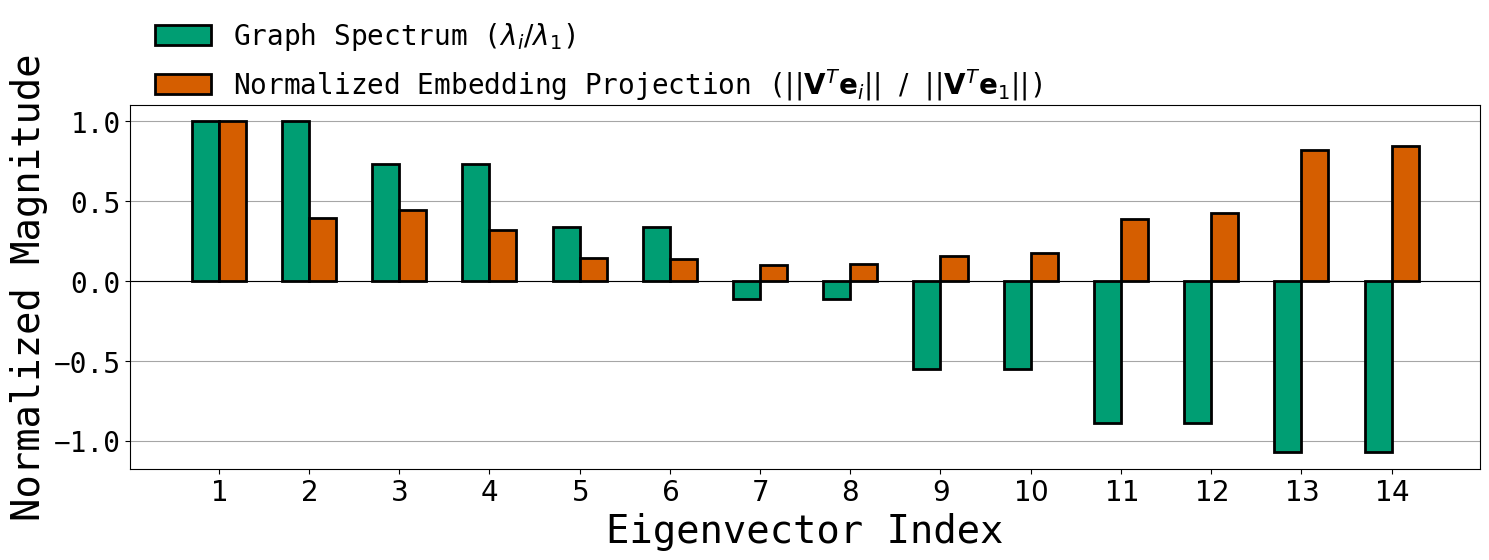

In [33]:
# Spectral-bias constants for this block
cycle_v3_spectral_drop_top_eigenvector = True
cycle_v3_spectral_reorder_prefix = None
cycle_v3_spectral_cutoff = None
cycle_v3_spectral_figsize = (15.0, 6.0)
cycle_v3_spectral_legend_anchor = (0.0, 1.3)

cycle_v3_norm_eigenvalues, cycle_v3_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v3_node_embeddings,
    spectral_state=cycle_v3_spectral_state,
    drop_top_eigenvector=cycle_v3_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v3_spectral_reorder_prefix,
)

print("cycle normalized eigenvalues:\n", cycle_v3_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=cycle_v3_norm_eigenvalues,
    norm_projections=cycle_v3_norm_projections,
    title="",
    cutoff=cycle_v3_spectral_cutoff,
    figsize=cycle_v3_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v3_spectral_legend_anchor,
    save=True,
    filename=f"{cycle_v3_context.args.graph_type}_{cycle_v3_context.args.model_architecture_label}_eigen_projection_v3"
);


## 4) Tiny cycle (No Weight Decay/Dropout -- Tiny LR)


In [34]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [56]:
cycle_v4_seed = 7

cycle_v4_train_from_scratch = True
cycle_v4_checkpoint_path = ""
cycle_v4_embedding_history_path = ""
cycle_v4_topk_history_path = ""
cycle_v4_dataset_overwrite = False

cycle_v4_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 5e-5,
    "--edge_memorization_epochs": 10000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0., # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [57]:
cycle_v4_context = build_transformer_section_context(
    cycle_v4_cli_config,
    seed=cycle_v4_seed,
    dataset_overwrite=cycle_v4_dataset_overwrite,
)

cycle_v4_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v4_context,
    train_from_scratch=cycle_v4_train_from_scratch,
    checkpoint_path=cycle_v4_checkpoint_path,
)

print("Run name:", cycle_v4_context.args.run_name)
print("Checkpoint:", cycle_v4_resolved_checkpoint_path)
print("Pretrain file:", cycle_v4_context.pretrain_path)
print("Train file:", cycle_v4_context.train_path)
print("Test file:", cycle_v4_context.test_path)
print("Archived checkpoint:", cycle_v4_context.checkpoint_path)
print("Embedding history pickle:", cycle_v4_context.embedding_history_path)
print("Top-k pickle:", cycle_v4_context.topk_history_path)
print("Manifest:", cycle_v4_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Edge accuracy improved to 6.67%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr5e-05x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215857/checkpoints/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr5e-05x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215857_edge_memorization_best.pt

Edge accuracy improved to 10.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr5e-05x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260406-215857/checkpoints/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr5e-05x0p005_tl0-rev0-sd00-f

In [58]:
cycle_v4_eval_metrics = evaluate_edge_and_path(cycle_v4_context)

print_evaluation_report("Tiny cycle (V4)", cycle_v4_eval_metrics)


Edge Memorization | Loss: 1.1422 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 122.66it/s]


Edge Memorization | Loss: 1.1422 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 88.13it/s]

Tiny cycle (V4) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [59]:
cycle_v4_node_embeddings, cycle_v4_edge_list, cycle_v4_root_node_index = collect_embeddings_and_edges(cycle_v4_context)

cycle_v4_embedding_history, cycle_v4_topk_recovery_history = load_analysis_histories(
    cycle_v4_context,
    cycle_v4_edge_list,
    embedding_history_path=cycle_v4_embedding_history_path,
    topk_history_path=cycle_v4_topk_history_path,
)

if not cycle_v4_embedding_history:
    cycle_v4_embedding_history = {0: cycle_v4_node_embeddings}
if not cycle_v4_topk_recovery_history:
    cycle_v4_topk_recovery_history = {0: cycle_v4_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v4_node_embeddings.shape)
print("Number of edges:", len(cycle_v4_edge_list))
print("Root node index:", cycle_v4_root_node_index)
print("Embedding history steps:", len(cycle_v4_embedding_history))
print("Top-k history steps:", len(cycle_v4_topk_recovery_history))


Node embedding shape: (15, 32)
Number of edges: 30
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [60]:
# Reduction config for this block (kept local to reduction stage)
cycle_v4_use_umap = False
cycle_v4_reduction_dim = 5
cycle_v4_umap_n_neighbors = 4
cycle_v4_umap_min_dist = 0.3

cycle_v4_reduced_full, cycle_v4_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v4_node_embeddings,
    use_umap=cycle_v4_use_umap,
    reduction_dim=cycle_v4_reduction_dim,
    seed=cycle_v4_seed,
    umap_n_neighbors=cycle_v4_umap_n_neighbors,
    umap_min_dist=cycle_v4_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v4_reduced_embeddings = cycle_v4_reduced_full[:, :3]
print("Reduced full shape:", cycle_v4_reduced_full.shape)
print("Reduced xyz shape:", cycle_v4_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

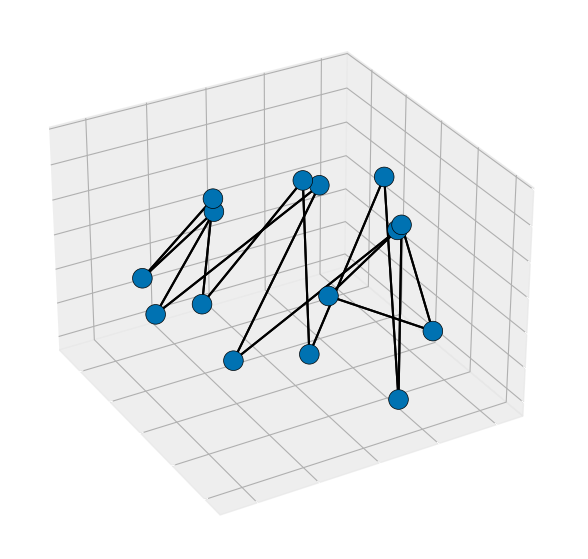

In [61]:
%matplotlib inline
# %matplotlib widget

cycle_v4_raw_elev = 30
cycle_v4_raw_azim = -30
cycle_v4_raw_roll = 0

# Styled plotting constants for this block
cycle_v4_styled_view = {"elev": cycle_v4_raw_elev, "azim": cycle_v4_raw_azim, "roll": cycle_v4_raw_roll}
cycle_v4_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v4_reduced_embeddings,
    cycle_v4_edge_list,
    title="",
    view=cycle_v4_styled_view,
    root_node_index=cycle_v4_root_node_index,
    axis_permutation=cycle_v4_styled_axis_permutation,
);


################
#Another Angle
################

# cycle_v4_raw_elev = 20
# cycle_v4_raw_azim = 0
# cycle_v4_raw_roll = 0

# # Styled plotting constants for this block
# cycle_v4_styled_view = {"elev": cycle_v4_raw_elev, "azim": cycle_v4_raw_azim, "roll": cycle_v4_raw_roll}
# cycle_v4_styled_axis_permutation = (0, 1, 2)

# plot_stylized_embedding_graph(
#     cycle_v4_reduced_embeddings,
#     cycle_v4_edge_list,
#     title="",
#     view=cycle_v4_styled_view,
#     root_node_index=cycle_v4_root_node_index,
#     axis_permutation=cycle_v4_styled_axis_permutation,
# );

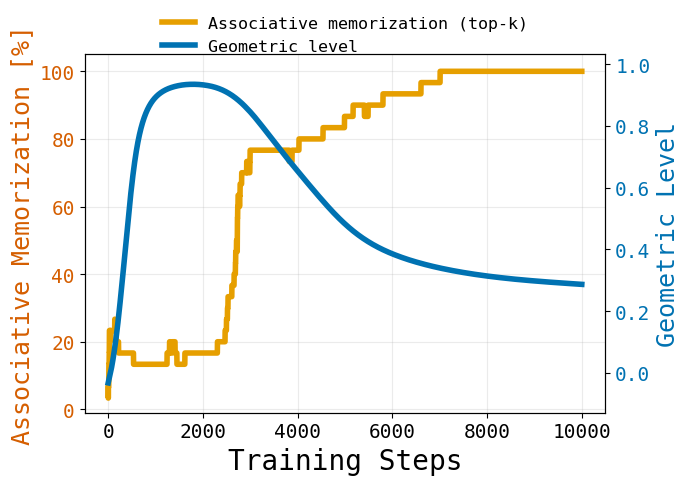

In [62]:
# Line-plot constants for this block
cycle_v4_line_plot_title = ""

cycle_v4_curve_steps, cycle_v4_curve_associative, cycle_v4_curve_geometric = compute_associative_geometric_curves(
    cycle_v4_embedding_history,
    cycle_v4_topk_recovery_history,
    cycle_v4_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v4_curve_steps,
    associative_scores=cycle_v4_curve_associative,
    geometric_scores=cycle_v4_curve_geometric,
    title=cycle_v4_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `cycle_heatmap_epoch` to one of the highest geometric_level epochs.

cycle heatmap epoch: 9999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


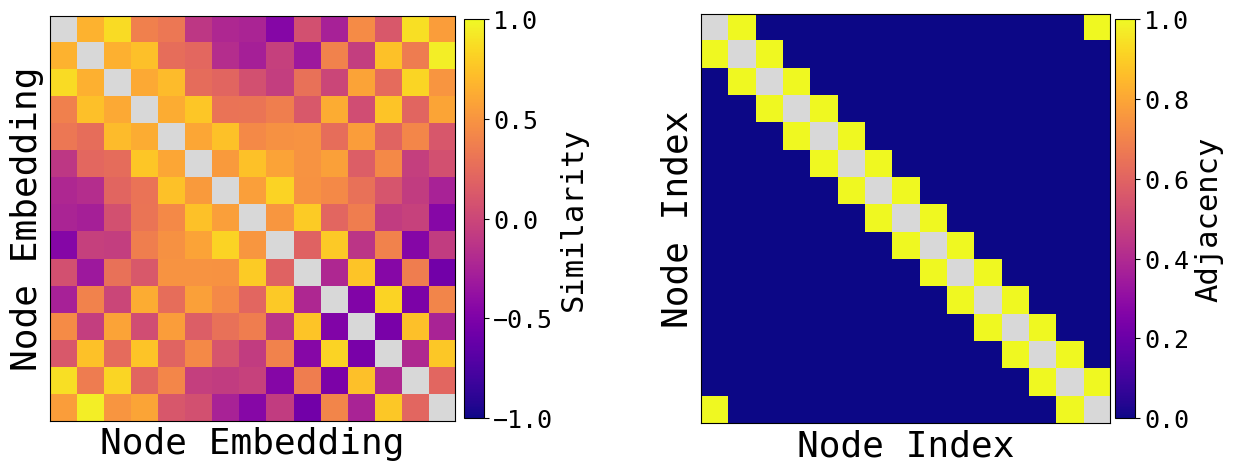

In [63]:
# Heatmap constants for this block
cycle_v4_heatmap_graph_type = cycle_v4_context.args.graph_type
cycle_v4_heatmap_epoch = -1
cycle_v4_heatmap_cmap_name = "plasma"
cycle_v4_heatmap_wspace = 0.5

cycle_v4_heatmap_embeddings, cycle_v4_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v4_embedding_history,
    fallback_embeddings=cycle_v4_node_embeddings,
    requested_step=cycle_v4_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v4_heatmap_resolved_epoch)
cycle_v4_heatmap_order = list(range(cycle_v4_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v4_heatmap_order), 4):
    row = cycle_v4_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v4_heatmap_embeddings,
    edge_list=cycle_v4_edge_list,
    graph_type=cycle_v4_heatmap_graph_type,
    root_node_index=cycle_v4_root_node_index,
    custom_order=cycle_v4_heatmap_order,
    cmap_name=cycle_v4_heatmap_cmap_name,
    wspace=cycle_v4_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [64]:
# Laplacian geometry constants for this block
cycle_v4_laplacian_axis_indices = (-2, -3, -4)
cycle_v4_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v4_edge_list,
    node_count=cycle_v4_node_embeddings.shape[0],
)

cycle normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]


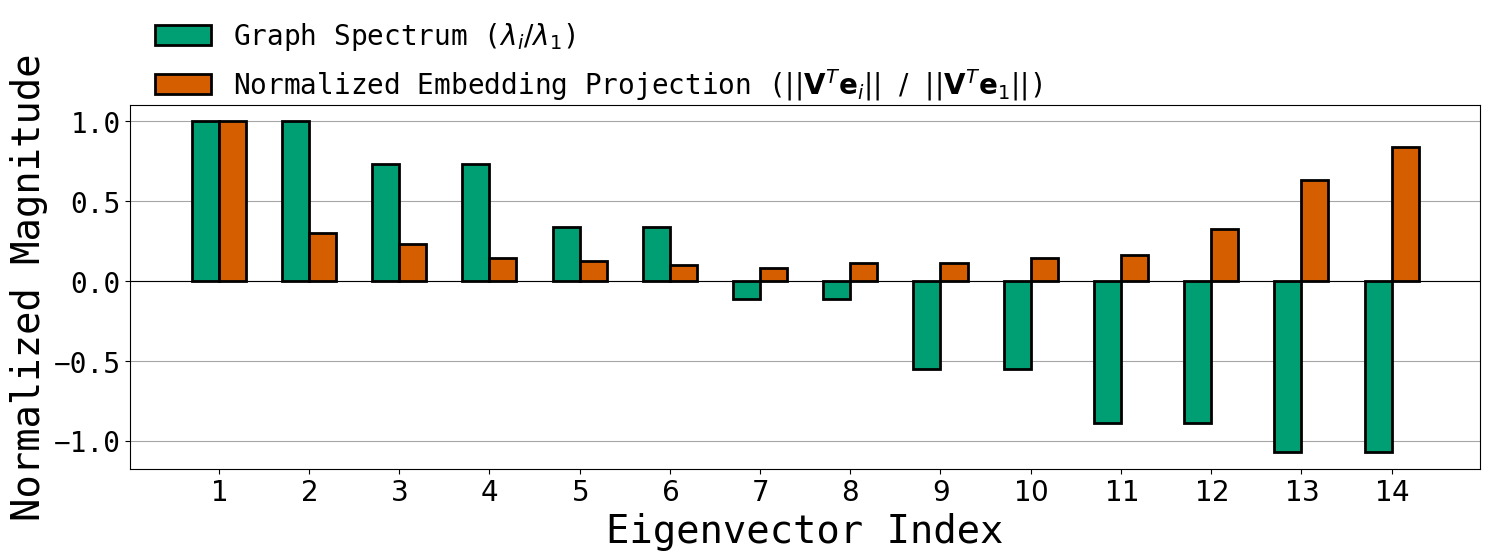

In [65]:
# Spectral-bias constants for this block
cycle_v4_spectral_drop_top_eigenvector = True
cycle_v4_spectral_reorder_prefix = None
cycle_v4_spectral_cutoff = None
cycle_v4_spectral_figsize = (15.0, 6.0)
cycle_v4_spectral_legend_anchor = (0.0, 1.3)

cycle_v4_norm_eigenvalues, cycle_v4_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v4_node_embeddings,
    spectral_state=cycle_v4_spectral_state,
    drop_top_eigenvector=cycle_v4_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v4_spectral_reorder_prefix,
)

print("cycle normalized eigenvalues:\n", cycle_v4_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=cycle_v4_norm_eigenvalues,
    norm_projections=cycle_v4_norm_projections,
    title="",
    cutoff=cycle_v4_spectral_cutoff,
    figsize=cycle_v4_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v4_spectral_legend_anchor,
    save=True,
    filename=f"{cycle_v4_context.args.graph_type}_{cycle_v4_context.args.model_architecture_label}_eigen_projection"
);


## 5) Tiny cycle with Self-Edges (Reasonable LR)


In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [2]:
cycle_v5_seed = 7

cycle_v5_train_from_scratch = True
cycle_v5_checkpoint_path = ""
cycle_v5_embedding_history_path = ""
cycle_v5_topk_history_path = ""
cycle_v5_dataset_overwrite = False

cycle_v5_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0., # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": True, # DIFFERENT FROM V1-V4, ADDS SELF-EDGES
}


In [3]:
cycle_v5_context = build_transformer_section_context(
    cycle_v5_cli_config,
    seed=cycle_v5_seed,
    dataset_overwrite=cycle_v5_dataset_overwrite,
)

cycle_v5_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v5_context,
    train_from_scratch=cycle_v5_train_from_scratch,
    checkpoint_path=cycle_v5_checkpoint_path,
)

print("Run name:", cycle_v5_context.args.run_name)
print("Checkpoint:", cycle_v5_resolved_checkpoint_path)
print("Pretrain file:", cycle_v5_context.pretrain_path)
print("Train file:", cycle_v5_context.train_path)
print("Test file:", cycle_v5_context.test_path)
print("Archived checkpoint:", cycle_v5_context.checkpoint_path)
print("Embedding history pickle:", cycle_v5_context.embedding_history_path)
print("Top-k pickle:", cycle_v5_context.topk_history_path)
print("Manifest:", cycle_v5_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/1000 [00:00<?, ?it/s]


Edge accuracy improved to 33.33%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260406-220129/checkpoints/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260406-220129_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 33.33%
Run name: in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260406-220129
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D32-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge1-task

In [4]:
cycle_v5_eval_metrics = evaluate_edge_and_path(cycle_v5_context)

print_evaluation_report("Tiny cycle (V5)", cycle_v5_eval_metrics)


Edge Memorization | Loss: 1.1196 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 84.74it/s]


Edge Memorization | Loss: 1.1196 | Acc: 33.33%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 85.87it/s]

Tiny cycle (V5) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [5]:
cycle_v5_node_embeddings, cycle_v5_edge_list, cycle_v5_root_node_index = collect_embeddings_and_edges(cycle_v5_context)

cycle_v5_embedding_history, cycle_v5_topk_recovery_history = load_analysis_histories(
    cycle_v5_context,
    cycle_v5_edge_list,
    embedding_history_path=cycle_v5_embedding_history_path,
    topk_history_path=cycle_v5_topk_history_path,
)

if not cycle_v5_embedding_history:
    cycle_v5_embedding_history = {0: cycle_v5_node_embeddings}
if not cycle_v5_topk_recovery_history:
    cycle_v5_topk_recovery_history = {0: cycle_v5_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v5_node_embeddings.shape)
print("Number of edges:", len(cycle_v5_edge_list))
print("Root node index:", cycle_v5_root_node_index)
print("Embedding history steps:", len(cycle_v5_embedding_history))
print("Top-k history steps:", len(cycle_v5_topk_recovery_history))


Node embedding shape: (15, 32)
Number of edges: 45
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [6]:
# Reduction config for this block (kept local to reduction stage)
cycle_v5_use_umap = False
cycle_v5_reduction_dim = 5
cycle_v5_umap_n_neighbors = 4
cycle_v5_umap_min_dist = 0.3

cycle_v5_reduced_full, cycle_v5_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v5_node_embeddings,
    use_umap=cycle_v5_use_umap,
    reduction_dim=cycle_v5_reduction_dim,
    seed=cycle_v5_seed,
    umap_n_neighbors=cycle_v5_umap_n_neighbors,
    umap_min_dist=cycle_v5_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v5_reduced_embeddings = cycle_v5_reduced_full[:, :3]
print("Reduced full shape:", cycle_v5_reduced_full.shape)
print("Reduced xyz shape:", cycle_v5_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

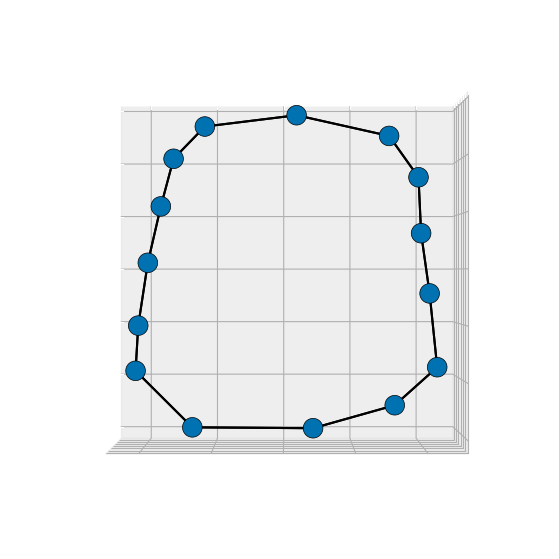

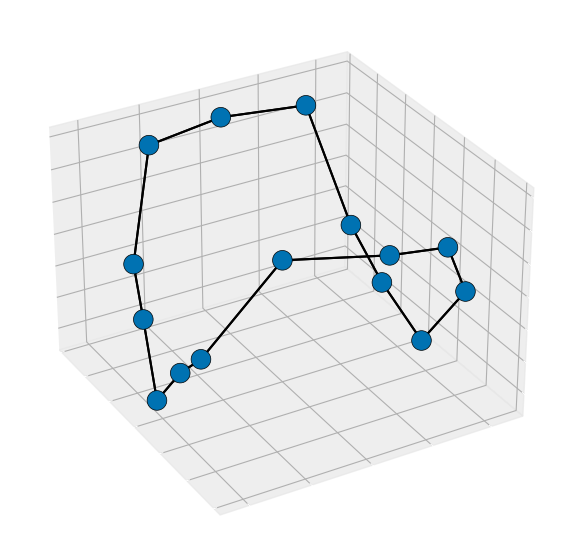

In [58]:
%matplotlib inline
# %matplotlib widget

cycle_v5_raw_elev = 90
cycle_v5_raw_azim = 0
cycle_v5_raw_roll = 0

# Styled plotting constants for this block
cycle_v5_styled_view = {"elev": cycle_v5_raw_elev, "azim": cycle_v5_raw_azim, "roll": cycle_v5_raw_roll}
cycle_v5_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v5_reduced_embeddings,
    cycle_v5_edge_list,
    title="",
    view=cycle_v5_styled_view,
    root_node_index=cycle_v5_root_node_index,
    axis_permutation=cycle_v5_styled_axis_permutation,
);

################
#Another Angle
################

cycle_v5_raw_elev = 30
cycle_v5_raw_azim = -30
cycle_v5_raw_roll = 0

# Styled plotting constants for this block
cycle_v5_styled_view = {"elev": cycle_v5_raw_elev, "azim": cycle_v5_raw_azim, "roll": cycle_v5_raw_roll}
cycle_v5_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v5_reduced_embeddings,
    cycle_v5_edge_list,
    title="",
    view=cycle_v5_styled_view,
    root_node_index=cycle_v5_root_node_index,
    axis_permutation=cycle_v5_styled_axis_permutation,
);



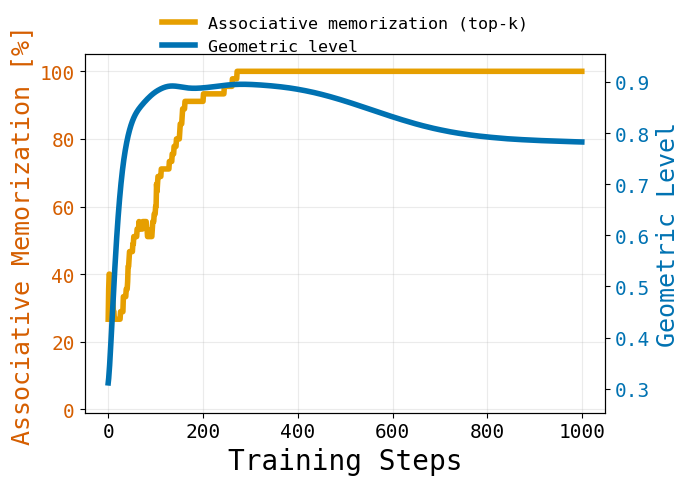

In [59]:
# Line-plot constants for this block
cycle_v5_line_plot_title = ""

cycle_v5_curve_steps, cycle_v5_curve_associative, cycle_v5_curve_geometric = compute_associative_geometric_curves(
    cycle_v5_embedding_history,
    cycle_v5_topk_recovery_history,
    cycle_v5_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v5_curve_steps,
    associative_scores=cycle_v5_curve_associative,
    geometric_scores=cycle_v5_curve_geometric,
    title=cycle_v5_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `cycle_heatmap_epoch` to one of the highest geometric_level epochs.

cycle heatmap epoch: 999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


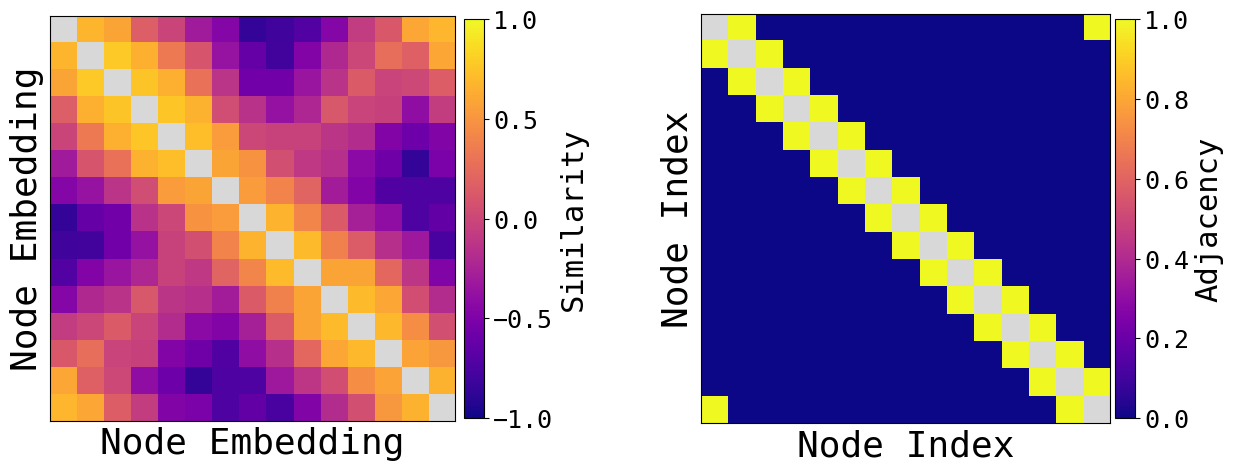

In [60]:
# Heatmap constants for this block
cycle_v5_heatmap_graph_type = cycle_v5_context.args.graph_type
cycle_v5_heatmap_epoch = -1
cycle_v5_heatmap_cmap_name = "plasma"
cycle_v5_heatmap_wspace = 0.5

cycle_v5_heatmap_embeddings, cycle_v5_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v5_embedding_history,
    fallback_embeddings=cycle_v5_node_embeddings,
    requested_step=cycle_v5_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v5_heatmap_resolved_epoch)
cycle_v5_heatmap_order = list(range(cycle_v5_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v5_heatmap_order), 4):
    row = cycle_v5_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v5_heatmap_embeddings,
    edge_list=cycle_v5_edge_list,
    graph_type=cycle_v5_heatmap_graph_type,
    root_node_index=cycle_v5_root_node_index,
    custom_order=cycle_v5_heatmap_order,
    cmap_name=cycle_v5_heatmap_cmap_name,
    wspace=cycle_v5_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [61]:
# Laplacian geometry constants for this block
cycle_v5_laplacian_axis_indices = (-2, -3, -4)
cycle_v5_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v5_edge_list,
    node_count=cycle_v5_node_embeddings.shape[0],
)

cycle v5 normalized eigenvalues:
 [ 1.     1.     0.827  0.827  0.572  0.572  0.28   0.28  -0.     0.
 -0.219 -0.219 -0.338 -0.338]


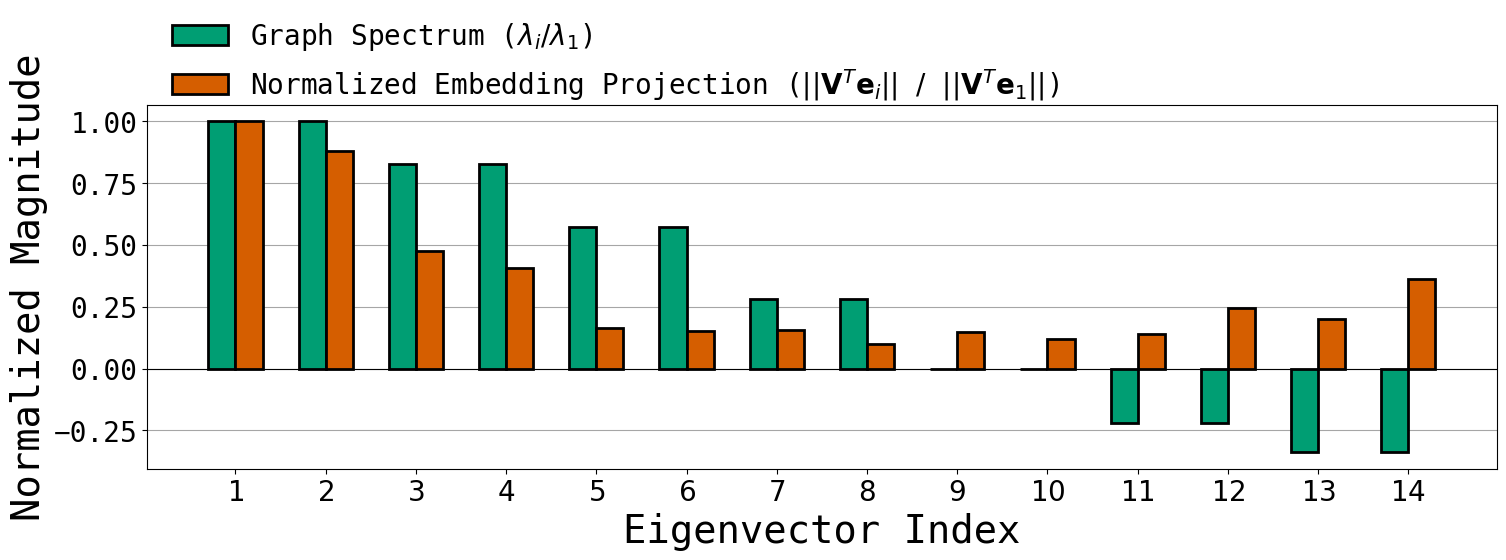

In [62]:
# Spectral-bias constants for this block
cycle_v5_spectral_drop_top_eigenvector = True
cycle_v5_spectral_reorder_prefix = None
cycle_v5_spectral_cutoff = None
cycle_v5_spectral_figsize = (15.0, 6.0)
cycle_v5_spectral_legend_anchor = (0.0, 1.3)

cycle_v5_norm_eigenvalues, cycle_v5_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v5_node_embeddings,
    spectral_state=cycle_v5_spectral_state,
    drop_top_eigenvector=cycle_v5_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v5_spectral_reorder_prefix,
)

print("cycle v5 normalized eigenvalues:\n", cycle_v5_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=cycle_v5_norm_eigenvalues,
    norm_projections=cycle_v5_norm_projections,
    title="",
    cutoff=cycle_v5_spectral_cutoff,
    figsize=cycle_v5_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v5_spectral_legend_anchor,
    save=True,
    filename=f"{cycle_v5_context.args.graph_type}_{cycle_v5_context.args.model_architecture_label}_eigen_projection"
);
